In [ ]:
import numpy as np                                                   # numerical computing library
import matplotlib.pyplot as plt                                      # plotting library
import scipy.integrate as spi                                        # scientific library — ODE solvers
import os                                                            # operating system interface
os.chdir(r'C:/Users/Giannis/.vscode/03_pharmacokinetics_simulator')  # set working directory

def two_compartment(t, y, k12, k21, ke):
    # ODE system — defines rate of change for both compartments
    # note: solve_ivp requires (t, y) order — opposite of odeint
    """
    Two compartment model:
    Compartment 1 = blood/plasma (central)
    Compartment 2 = tissue (peripheral)

    y[0] = C1 = drug concentration in blood (mg/L)
    y[1] = C2 = drug concentration in tissue (mg/L)
    k12  = transfer rate blood → tissue (1/hour)
    k21  = transfer rate tissue → blood (1/hour)
    ke   = elimination rate from blood (1/hour)
    """
    C1, C2 = y                              # unpack concentrations
    dC1dt = -k12 * C1 + k21 * C2 - ke * C1  # blood: loses drug to tissue and elimination, gains from tissue
    dC2dt = k12 * C1 - k21 * C2             # tissue: gains from blood, loses back to blood
    return [dC1dt, dC2dt]                   # return both derivatives

# Parameters
C0 = [100.0, 0.0]                  # initial dose in blood (mg/L), zero in tissue
k12 = 0.3                          # blood → tissue transfer rate (1/hour)
k21 = 0.1                          # tissue → blood transfer rate (1/hour)
ke = 0.15                          # elimination rate from blood (1/hour)
t_span = (0, 48)                   # simulation window: 0 to 48 hours
t_eval = np.linspace(0, 48, 1000)  # 1000 time points to evaluate

# Solve coupled ODE system
solution = spi.solve_ivp(
    fun=two_compartment,    # ODE function to integrate
    t_span=t_span,          # time interval
    y0=C0,                  # initial concentrations
    t_eval=t_eval,          # time points to record
    args=(k12, k21, ke),    # extra parameters passed to two_compartment
    method='RK45'           # Runge-Kutta 4/5 adaptive solver
)

C1 = solution.y[0]          # extract blood concentration array
C2 = solution.y[1]          # extract tissue concentration array
t = solution.t              # extract time array

# Key metrics
half_life = np.log(2) / ke             # t½ = ln(2)/ke
peak_tissue = np.max(C2)               # maximum tissue concentration
peak_tissue_time = t[np.argmax(C2)]    # time of peak tissue concentration

print(f'Half life: {half_life:.1f} hours')
print(f'Peak tissue concentration: {peak_tissue:.2f} mg/L')
print(f'Time to peak tissue concentration: {peak_tissue_time:.1f} hours')
print(f'Solver status: {solution.message}')  # confirms solver succeeded

Half life: 4.6 hours
Peak tissue concentration: 48.59 mg/L
Time to peak tissue concentration: 5.9 hours
Solver status: The solver successfully reached the end of the integration interval.


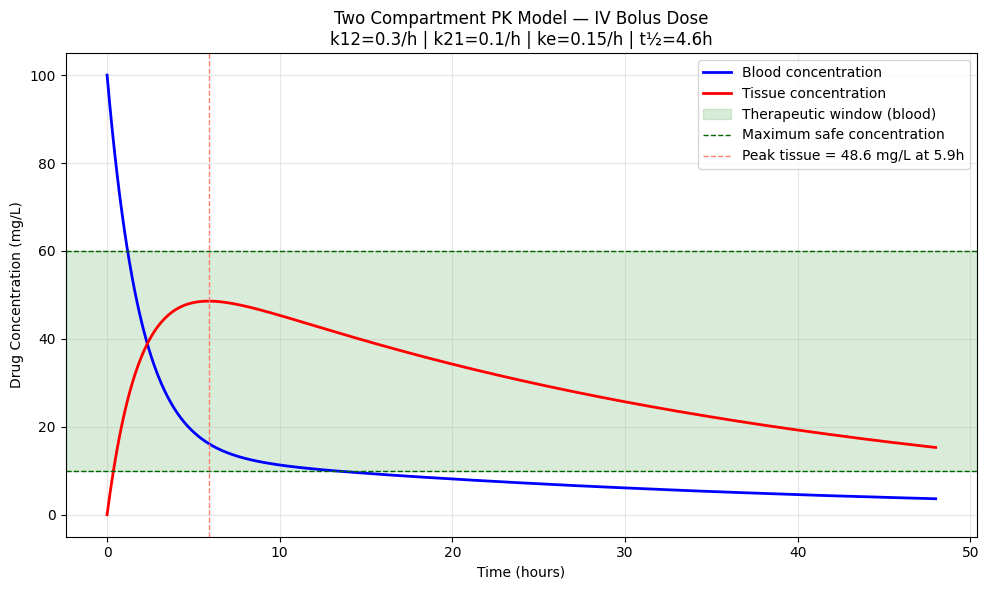

In [33]:
C_min = 10.0    # minimum effective concentration (mg/L)
C_max = 60.0    # maximum safe concentration (mg/L)

plt.figure(figsize=(10, 6))   # create figure

plt.plot(t, C1, color='blue', linewidth=2, label='Blood concentration')   # blood concentration curve
plt.plot(t, C2, color='red', linewidth=2, label='Tissue concentration')   # tissue concentration curve

plt.axhspan(C_min, C_max, alpha=0.15, color='green', label='Therapeutic window (blood)')                # shade safe zone
plt.axhline(C_min, color='darkgreen', linestyle='--', linewidth=1)                                      # minimum effective line
plt.axhline(C_max, color='darkgreen', linestyle='--', linewidth=1, label='Maximum safe concentration')  # toxic level line

plt.axvline(peak_tissue_time, color='salmon', linestyle='--',
            linewidth=1,
            label=f'Peak tissue = {peak_tissue:.1f} mg/L at {peak_tissue_time:.1f}h')  # peak tissue marker

plt.xlabel('Time (hours)')
plt.ylabel('Drug Concentration (mg/L)')
plt.title(f'Two Compartment PK Model — IV Bolus Dose\n'
          f'k12={k12}/h | k21={k21}/h | ke={ke}/h | t½={half_life:.1f}h')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/02_two_compartment.png', bbox_inches='tight')  # save to results
plt.show()

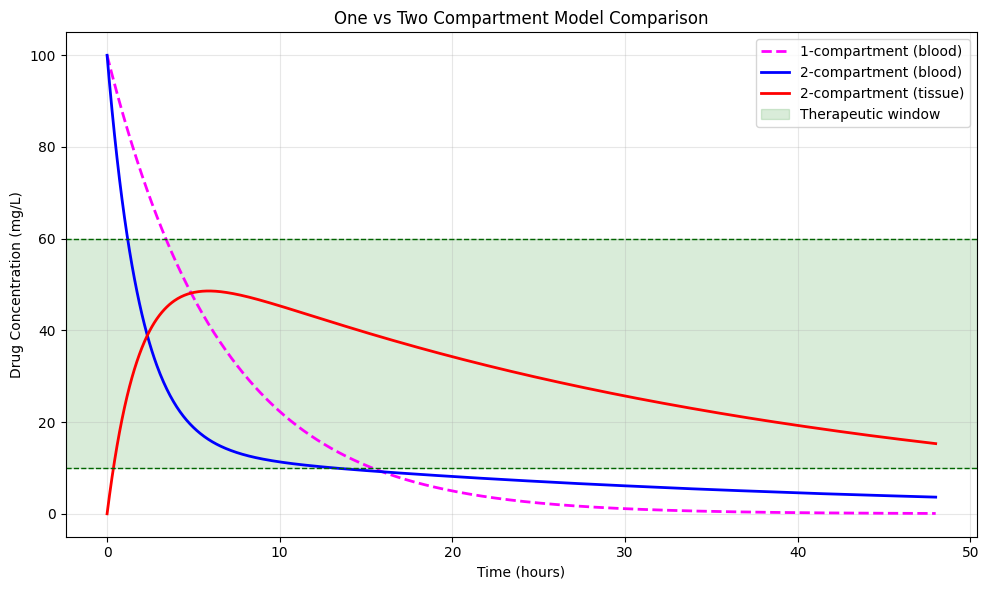

In [34]:
def one_compartment(t, C, ke):
    # one compartment ODE for comparison — simple elimination only
    dCdt = -ke * C[0]   # first order elimination
    return [dCdt]       # return derivative as list

# Solve one compartment model
solution_one = spi.solve_ivp(
    fun=one_compartment,    # simple elimination ODE
    t_span=t_span,          # same time window
    y0=[100.0],             # same initial dose
    t_eval=t_eval,          # same time points
    args=(ke,),             # elimination rate
    method='RK45'           # same solver
)

C1_one = solution_one.y[0]  # extract one compartment blood concentration

plt.figure(figsize=(10, 6))

plt.plot(t, C1_one, color='magenta', linewidth=2, linestyle='--', label='1-compartment (blood)')  # dashed = simpler model
plt.plot(t, C1, color='blue', linewidth=2, label='2-compartment (blood)')                         # solid = realistic model
plt.plot(t, C2, color='red', linewidth=2, label='2-compartment (tissue)')                         # tissue reservoir

plt.axhspan(C_min, C_max, alpha=0.15, color='green', label='Therapeutic window')     # safe zone
plt.axhline(C_min, color='darkgreen', linestyle='--', linewidth=1)
plt.axhline(C_max, color='darkgreen', linestyle='--', linewidth=1)

plt.xlabel('Time (hours)')
plt.ylabel('Drug Concentration (mg/L)')
plt.title('One vs Two Compartment Model Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/02_model_comparison.png', bbox_inches='tight')  # save to results
plt.show()